This notebook tests basic simulation by recapitulating a simulated dataset several times and measuring variance.

Imports

In [1]:
import sys
import os
package_path = os.path.abspath("..")
sys.path.insert(0, package_path)
#The path will be managed by conda or whatever on release, but this is fine for now.
import scMPRAforge as scm
import pandas as pd
import numpy as np

In [1]:
#load the autoreload extension
%load_ext autoreload
#reload code on every execution
#(this may break objects)
#you can remove this & do dev in a notebook, then paste into the module when you are done.
%autoreload 2

In [2]:
#dask imports
from dask_jobqueue import SLURMCluster
from dask.distributed import Client, LocalCluster
import socket

Make the dask cluster & client in accordance with resource avail and model size

In [3]:
cluster=LocalCluster()
#cluster=SLURMCluster(
#    cores=2,#cores per slurm job
#    memory="16G",#memory per slurm job
#    processes=1,#dask workers per slurm job
#    job_extra_directives=["-p ycga", 
#        f"--job-name=simclust_worker",
#        f"--time=2:00:00",
#        f"--output=slave_%j.out"]
#)
client = Client(cluster,
    timeout=f"{5*60}s",   # Client <-> scheduler timeout 
    heartbeat_interval="20s"  # Worker heartbeat interval
)

2025-06-09 14:45:16,492 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle ced67d7286955cf7fcedafe50502248d initialized by task ('shuffle-transfer-ced67d7286955cf7fcedafe50502248d', 1) executed on worker tcp://127.0.0.1:53688
2025-06-09 14:45:16,512 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle c2593db2b4eff542af0fbda16ecee64d initialized by task ('shuffle-transfer-c2593db2b4eff542af0fbda16ecee64d', 1) executed on worker tcp://127.0.0.1:53688
2025-06-09 14:45:16,695 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle c2593db2b4eff542af0fbda16ecee64d deactivated due to stimulus 'task-finished-1749494716.6947572'
2025-06-09 14:45:16,778 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle ced67d7286955cf7fcedafe50502248d deactivated due to stimulus 'task-finished-1749494716.777405'
2025-06-09 14:45:27,512 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle ced67d7286955cf7fcedafe50502248d initialized by task ('shuffle-transfer-ced67d7286955cf

In [4]:
#cluster.scale(jobs=5)

In [4]:
dat=scm.load_scMPRA_data("/gpfs/gibbs/pi/reilly/tabula_data/simulated/fake_cres.tsv")

In [5]:
dat.drop("Unnamed: 0", axis=1, inplace=True)

In [6]:
#let's make an ortho object out of the data on disc, we'll call 'primordial'
primordial=scm.ortho()
primordial.criss_cross(client=client,dat=dat)
primordial.extract_params(client)

In [7]:
# break out data-frame descriptions of the by-cre and by-cell-type parameters.
description_primordial_by_cre=scm.describe_parameters(client,parameters=primordial.by_cre_parameters.result(),dat=dat,split="cre_id")
description_primordial_by_cre=scm.auto_partition(description_primordial_by_cre,50)

description_primordial_by_cell_type=scm.describe_parameters(client,parameters=primordial.by_cell_type_parameters.result(),dat=dat,split="cell_type")
description_primordial_by_cell_type=scm.auto_partition(description_primordial_by_cell_type,50)


In [119]:
def split_dataframe_by_column(df, column):
    """
    Splits a DataFrame into a dictionary of DataFrames based on unique values in a given column.

    Parameters:
    df (pd.DataFrame): The input DataFrame.
    column (str): The column name to split on.

    Returns:
    dict: A dictionary where keys are unique column values and values are DataFrames.
    """
    return {value: sub_df for value, sub_df in df.groupby(column)}

def bust_up(working, split):
    """Breaks a round of simulation into sub-tables, one for each of the major parameters in the zinb"""
    drop_from_zi=[i for i in ['cre_id','cells','nb','theta','p','r','sigmasquare','cell_type'] if i != split]
    zi=working.drop(columns=drop_from_zi)
    zi=zi.drop_duplicates()#.groupby("rep_id").agg('mean')# zi
    
    nb=working.drop(columns=['rep_id','cells','zi','theta','r','p','sigmasquare']).drop_duplicates()# nb
    
    #for theta, we have only one value per model : one value per value of split column. 
    #this means we want to drop the anti-split column, since this provides no info
    theta_to_drop=[i for i in working.columns.to_list() if i not in [split,'theta']]
    theta=working.drop(columns=theta_to_drop).drop_duplicates()
    return {'zi':zi,'nb':nb,'theta':theta}

def round_of_simu(client,description_primordial):
    """
    Given a description of parameters, simulate a round of data, fit a description & return
    """
    #s for simulated
    s=scm.simulate_from_description(description_primordial).compute()
    
    s=scm.undo_one_hot_encoding(s)
    s=s.rename({'zinb_sample':'umis_mpra_bc'},axis=1)[['rep_id','cre_id','cell_type','umis_mpra_bc']]

    #recap as in recapitulating the primordial parameters
    recap=scm.ortho()
    recap.criss_cross(client=client,dat=s)
    recap.extract_params(client)

    return recap



In [122]:
#first is primordial, second is fit
from_cre=[]
from_cell_type=[]

for _ in range(1,5):
    from_cre.append(round_of_simu(client,description_primordial_by_cre))
    from_cell_type.append(round_of_simu(client,description_primordial_by_cell_type))
    #cre_to_cell_type.append(round_of_simu(description_primordial_by_cre,split="cell_type"))

In [149]:
flatten_results_nb(from_cell_type[0],split="by_cre")

,cre_id,nb,cell_type
0,redgene,104.219838,blood
1,redgene,30.886548,brain
2,neurogene,16.080984,blood
3,neurogene,97.538336,brain
4,everybody,104.703055,blood
5,everybody,106.124230,brain
6,somebody,12.182689,blood
7,somebody,10.070090,brain
8,nobody,1.691914,blood
9,nobody,0.893763,brain


In [167]:
splits=["cre_id","cell_type"]

nbs=[]



def flatten_results_nb(working,split):
    if split=="cre_id":
        working=working.by_cre_parameters.result()
    elif split=="cell_type":
        working=working.by_cell_type_parameters.result()
    working=pd.concat(working.nb)
    working.index=working.index.set_names(split,level=0)
    working=working.reset_index()
    working=scm.undo_one_hot_encoding(working)
    
    return working

for split in splits:
    prim_flattened=flatten_results_nb(primordial,split)
    prim_flattened["id"]=f"primordial {split}"
    prim_flattened["rep"]="primordial"
    nbs.append(prim_flattened)

for _from in splits:
    orthos=None
    if _from=="cre_id":
        orthos=from_cre
    else:
        orthos=from_cell_type
    
    for _to in splits:
        
        id_string=f"{_from}->{_to}"
        for i, ortho in enumerate(orthos):
            working=flatten_results_nb(ortho,split=_to)
            working['id']=id_string
            working['rep']=f"rep {i}"
            nbs.append(working)

nbs=pd.concat(nbs)

In [168]:
nbs

,cre_id,nb,cell_type,id,rep
0,nobody,1.772230,blood,primordial cre_id,primordial
1,nobody,0.928983,brain,primordial cre_id,primordial
2,somebody,12.439811,blood,primordial cre_id,primordial
3,somebody,9.989215,brain,primordial cre_id,primordial
4,everybody,103.512344,blood,primordial cre_id,primordial
...,...,...,...,...,...
5,everybody,100.805416,blood,cell_type->cell_type,rep 3
6,neurogene,15.608183,blood,cell_type->cell_type,rep 3
7,nobody,1.999833,blood,cell_type->cell_type,rep 3
8,redgene,104.857241,blood,cell_type->cell_type,rep 3


In [170]:
import seaborn as sns
import matplotlib.pyplot as plt

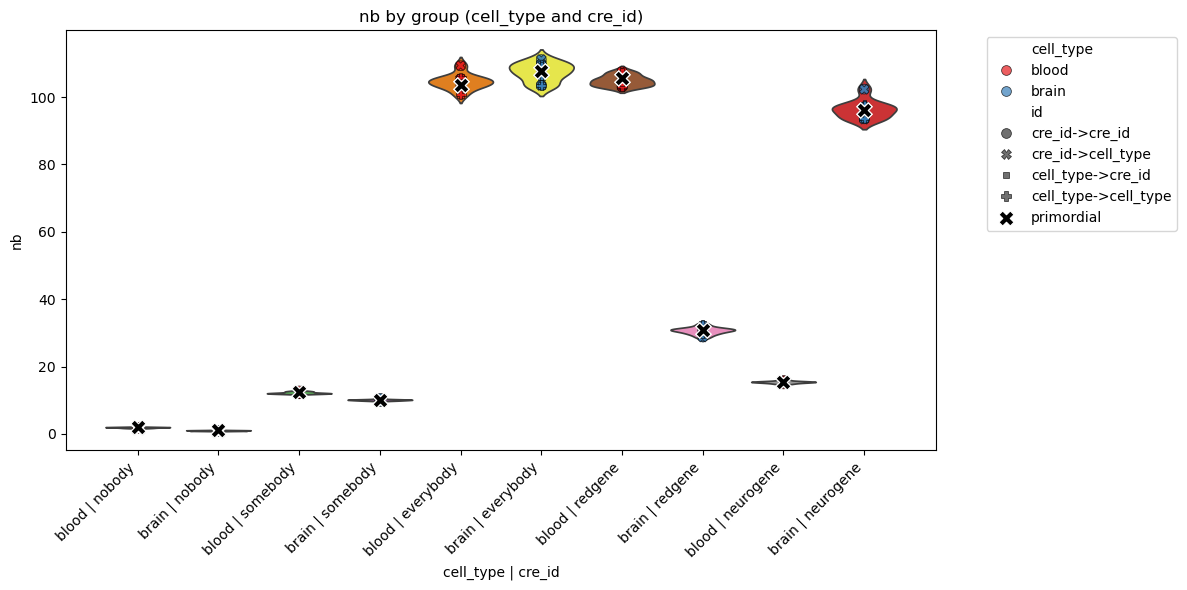

In [178]:


nbs['group'] = nbs['cell_type'] + " | " + nbs['cre_id']

plt.figure(figsize=(12, 6))

# Violin plot
sns.violinplot(
    data=nbs, x='group', y='nb',
    inner=None, palette='Set1'
)

# Regular points
sns.scatterplot(
    data=nbs[~nbs['id'].isin(['primordial cre_id', 'primordial cell_type'])],
    x='group', y='nb',
    hue='cell_type', style='id',
    palette='Set1', edgecolor='black', s=50, alpha=0.7, legend='brief'
)

# Primordial points overlay (bold black Xs)
sns.scatterplot(
    data=nbs[nbs['id'].isin(['primordial cre_id', 'primordial cell_type'])],
    x='group', y='nb',
    color='black', marker='X',
    s=120, label='primordial', zorder=10
)

plt.xlabel('cell_type | cre_id')
plt.ylabel('nb')
plt.title('nb by group (cell_type and cre_id)')
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

[        primordial
rep_id            
1         0.790788
2         0.497086
3         0.901153,         simulation_0
rep_id              
1           0.778663
2           0.453744
3           0.901929,         simulation_1
rep_id              
1           0.783317
2           0.514226
3           0.903632,         simulation_2
rep_id              
1           0.803808
2           0.499771
3           0.910169,         simulation_3
rep_id              
1           0.790607
2           0.487370
3           0.898500]


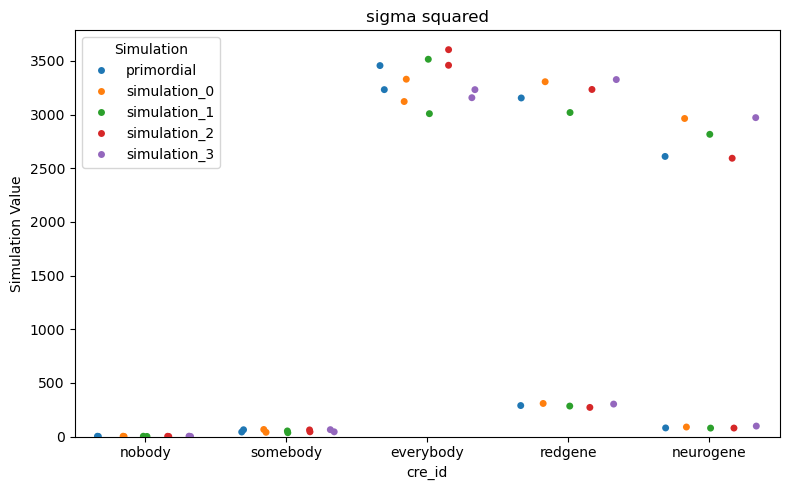

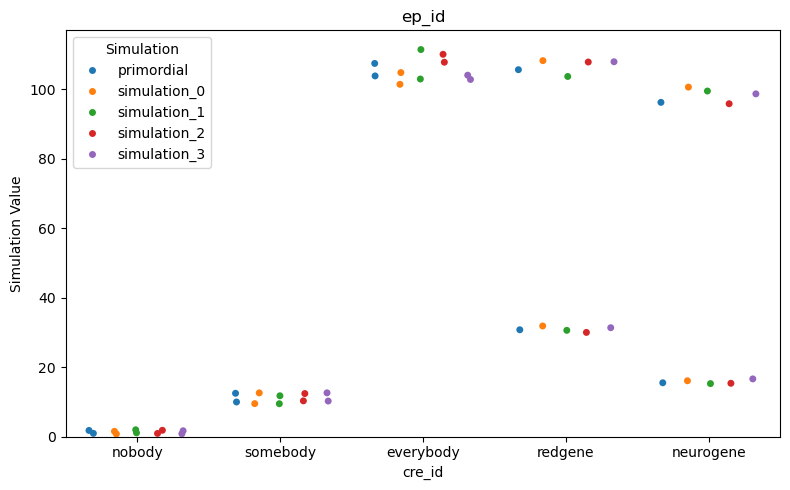

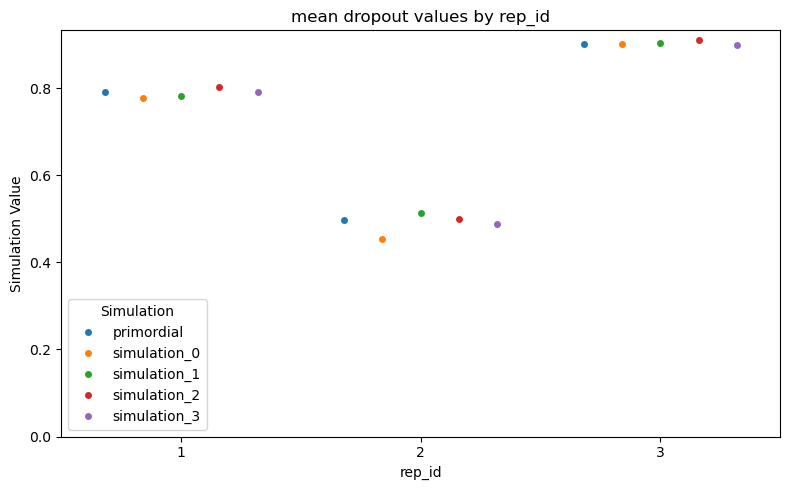

In [205]:
def plot(run):
    zi=[zi_p]
    nb=[nb_p]
    sigma=[sigma_p]
    #zi=[]
    #nb=[]
    #sigma=[]

    for index,dat in enumerate(run):
        df=dat["zi"]
        df=df.rename({"zi":f"simulation_{index}"},axis=1)
        zi.append(df)

        df=dat["nb"][['cre_id','nb']].rename({"nb":f"simulation_{index}"},axis=1)
        df.set_index('cre_id',inplace=True)
        nb.append(df)
        
        df=dat["nb"][['cre_id','sigmasquare']].rename({"sigmasquare":f"simulation_{index}"},axis=1)
        df.set_index('cre_id',inplace=True)
        sigma.append(df)
        #df=df
        
        #sigma.append(df[['cre_id','sigmasquare']])

    print(zi)

    nb_index=nb[0].index
    sigma_index=sigma[0].index

    nb = [df.reset_index(drop=True) for df in nb]
    sigma= [df.reset_index(drop=True) for df in sigma]

    zi=pd.concat(zi,axis=1)
    nb=pd.concat(nb,axis=1)
    sigma=pd.concat(sigma,axis=1)

    sigma.index=sigma_index
    nb.index=nb_index
    
    

    sigma_long= sigma.reset_index().melt(id_vars='cre_id',
                        var_name='simulation', 
                        value_name='value')

    nb_long= nb.reset_index().melt(id_vars='cre_id',var_name="simulation",value_name="value")
    plt.figure(figsize=(8, 5))
    sns.stripplot(data=sigma_long, x='cre_id', y='value', hue='simulation', jitter=True, dodge=True)
    plt.title("sigma squared")
    plt.ylabel("Simulation Value")
    plt.xlabel("cre_id")
    plt.legend(title='Simulation')
    plt.tight_layout()
    plt.ylim(bottom=0)
    plt.show()

    

    nb_long= nb.reset_index().melt(id_vars='cre_id',var_name="simulation",value_name="value")
    plt.figure(figsize=(8, 5))
    sns.stripplot(data=nb_long, x='cre_id', y='value', hue='simulation', jitter=True, dodge=True)
    plt.title("ep_id")
    plt.ylabel("Simulation Value")
    plt.xlabel("cre_id")
    plt.legend(title='Simulation')
    plt.tight_layout()
    plt.ylim(bottom=0)
    plt.show()

    

    zi_long = zi.reset_index().melt(id_vars='rep_id', 
                        var_name='simulation', 
                        value_name='value')
    
    plt.figure(figsize=(8, 5))
    sns.stripplot(data=zi_long, x='rep_id', y='value', hue='simulation', jitter=True, dodge=True)
    plt.title("mean dropout values by rep_id")
    plt.ylabel("Simulation Value")
    plt.xlabel("rep_id")
    plt.legend(title='Simulation')
    plt.tight_layout()
    plt.ylim(bottom=0)
    plt.show()
plot(cre_to_cre)

In [61]:
description_primordial_by_cre

,C(cell_type)[blood],C(cell_type)[brain],C(rep_id)[1],C(rep_id)[2],C(rep_id)[3],cre_id,cells,nb,zi,theta,r,sigmasquare,p
npartitions=2,,,,,,,,,,,,,
0,int64,int64,int64,int64,int64,string,int64,float64,float64,float32,float32,float64,float64
15,...,...,...,...,...,...,...,...,...,...,...,...,...
29,...,...,...,...,...,...,...,...,...,...,...,...,...


In [135]:
cluster.close()